<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/NVIDIA_Annual_Average_Prices_and_Trends_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NVIDIA Annual Average Prices and Trends

# About the dataset

Dataset, titled 'Updated Quality of Life Data.csv', comprises 10,000 entries with 8 features, offering insights into individual lifestyle habits and their potential impact on longevity. Each entry represents an individual, detailing their id, gender, occupation_type, avg_work_hours_per_day, avg_rest_hours_per_day, avg_sleep_hours_per_day, avg_exercise_hours_per_day, and age_at_death.

Upon initial inspection, the dataset is remarkably clean, with no missing values or duplicate entries, ensuring high data quality for analysis. The data types are appropriate for their respective columns, including numerical values for time-based features and age, and categorical types for gender and occupation.

Univariate Analysis Insights:

1. Gender: The distribution is almost balanced, with a slight majority of females (51.02%) over males (48.98%).
2. Occupation Type: There are 14 distinct occupation types, with 'Freelancer' being the most frequent. The counts are fairly distributed across other occupations like Teacher, Office Worker, and Scientist.
3. Lifestyle Hours: Histograms reveal interesting distributions. avg_work_hours_per_day peaks around 8-10 hours, but also shows a wide range, including some individuals working extremely long hours. avg_sleep_hours_per_day generally centers around 7-8 hours, while avg_rest_hours_per_day is more varied. avg_exercise_hours_per_day indicates that most individuals exercise for a short duration, with a long tail extending to higher hours.
4. Age at Death: The distribution of age_at_death appears to be concentrated in the higher age ranges, with a mean of approximately 79.85 years, and a minimum of 25 and a maximum of 100 years.

Bivariate Analysis Insights:

1. Correlations: The heatmap shows mild correlations. As expected, avg_work_hours_per_day generally has a negative correlation with avg_rest_hours_per_day and avg_sleep_hours_per_day. avg_exercise_hours_per_day shows a very weak positive correlation with age_at_death, suggesting that more exercise might be linked to a slightly longer lifespan, though this is not a strong relationship in this dataset.
2. Gender and Age at Death: Box plots comparing gender and age_at_death do not show significant differences, suggesting similar life expectancies between genders within this dataset. However, differences might exist in the distribution of lifestyle habits.
3. Occupation and Lifestyle: Different occupation_types exhibit variations in work, rest, and sleep hours. For example, managers and entrepreneurs might show higher average work hours, while manual laborers might have distinct patterns in rest and exercise. These variations could potentially influence age_at_death, forming interesting avenues for further investigation into specific occupational health and lifestyle trends.

Overall, the dataset offers a rich ground for exploring how daily habits and professional roles might interplay with lifespan, providing a foundation for predictive modeling or deeper causal inference studies.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d oluwatosinadewale/quality-of-life-data

# Unziping the downloaded file
!unzip quality-of-life-data.zip

Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/oluwatosinadewale/quality-of-life-data
License(s): CC0-1.0
  0% 0.00/131k [00:00<?, ?B/s]
100% 131k/131k [00:00<00:00, 387MB/s]
Archive:  quality-of-life-data.zip
  inflating: Updated Quality of Life Data.csv  


In [5]:
df = pd.read_csv('Updated Quality of Life Data.csv')
df.head(11)

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
0,10001,Female,Teacher,6.60,10.92,5.38,1.10,88
1,10002,Male,Office Worker,9.65,7.65,6.31,0.39,76
2,10003,Female,Manager,13.77,1.00,8.02,1.21,78
3,10004,Female,Freelancer,10.94,5.18,7.59,0.29,74
4,10005,Male,Engineer,9.81,5.11,7.38,1.70,78
5,10006,Female,Manual Laborer,8.74,10.02,4.39,0.85,87
6,10007,Male,Driver,10.66,3.18,8.66,1.50,64
7,10008,Female,Technician,20.69,2.42,0.88,0.00,51
8,10009,Female,Entrepreneur,15.77,1.00,6.20,1.03,63
9,10010,Female,Teacher,8.20,6.04,6.76,3.00,78


In [6]:
df.tail(11)

,id,gender,occupation_type,avg_work_hours_per_day,avg_rest_hours_per_day,avg_sleep_hours_per_day,avg_exercise_hours_per_day,age_at_death
9989,19990,Male,Retail Worker,8.43,6.41,7.21,1.95,74
9990,19991,Female,Consultant,7.28,7.12,7.17,2.43,96
9991,19992,Female,Retail Worker,8.26,5.05,9.91,0.78,79
9992,19993,Male,Office Worker,7.87,6.31,9.82,0.00,84
9993,19994,Female,Scientist,10.42,5.93,5.03,2.62,86
9994,19995,Male,Manual Laborer,11.99,4.54,6.03,1.45,69
9995,19996,Female,Technician,8.39,8.12,6.91,0.58,89
9996,19997,Male,Retail Worker,9.58,6.40,6.93,1.09,90
9997,19998,Female,Consultant,10.02,4.75,7.55,1.68,89
9998,19999,Female,Engineer,7.97,8.07,7.78,0.17,87


In [13]:
df.shape

(10000, 8)

In [7]:
df.columns

Index(['id', 'gender', 'occupation_type', 'avg_work_hours_per_day',
       'avg_rest_hours_per_day', 'avg_sleep_hours_per_day',
       'avg_exercise_hours_per_day', 'age_at_death'],
      dtype='object')

In [8]:
df.dtypes

,0
id,int64
gender,object
occupation_type,object
avg_work_hours_per_day,float64
avg_rest_hours_per_day,float64
avg_sleep_hours_per_day,float64
avg_exercise_hours_per_day,float64
age_at_death,int64


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          10000 non-null  int64  
 1   gender                      10000 non-null  object 
 2   occupation_type             10000 non-null  object 
 3   avg_work_hours_per_day      10000 non-null  float64
 4   avg_rest_hours_per_day      10000 non-null  float64
 5   avg_sleep_hours_per_day     10000 non-null  float64
 6   avg_exercise_hours_per_day  10000 non-null  float64
 7   age_at_death                10000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 625.1+ KB


In [10]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,10000.0,NaN,NaN,NaN,15000.5,2886.89568,10001.0,12500.75,15000.5,17500.25,20000.0
gender,10000,2,Female,5102,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation_type,10000,14,Freelancer,778,NaN,NaN,NaN,NaN,NaN,NaN,NaN
avg_work_hours_per_day,10000.0,NaN,NaN,NaN,9.211857,2.903739,0.01,7.74,8.96,10.44,23.97
avg_rest_hours_per_day,10000.0,NaN,NaN,NaN,5.964582,3.152097,0.0,3.89,5.83,7.67,23.93
avg_sleep_hours_per_day,10000.0,NaN,NaN,NaN,7.364192,2.214386,0.0,6.31,7.39,8.47,19.98
avg_exercise_hours_per_day,10000.0,NaN,NaN,NaN,1.459726,0.954428,0.0,0.65,1.44,2.25,5.93
age_at_death,10000.0,NaN,NaN,NaN,79.8506,12.02562,25.0,74.0,81.0,88.0,100.0


In [11]:
df.isnull().sum()

,0
id,0
gender,0
occupation_type,0
avg_work_hours_per_day,0
avg_rest_hours_per_day,0
avg_sleep_hours_per_day,0
avg_exercise_hours_per_day,0
age_at_death,0


In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

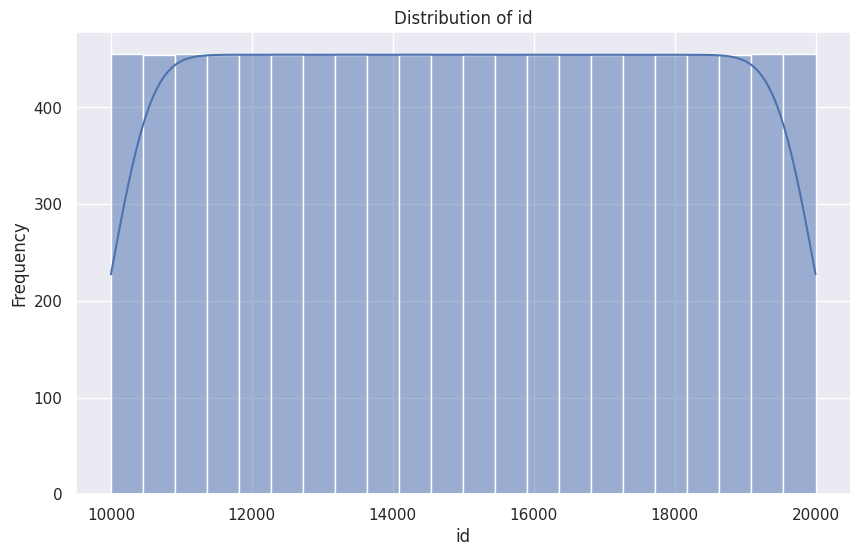

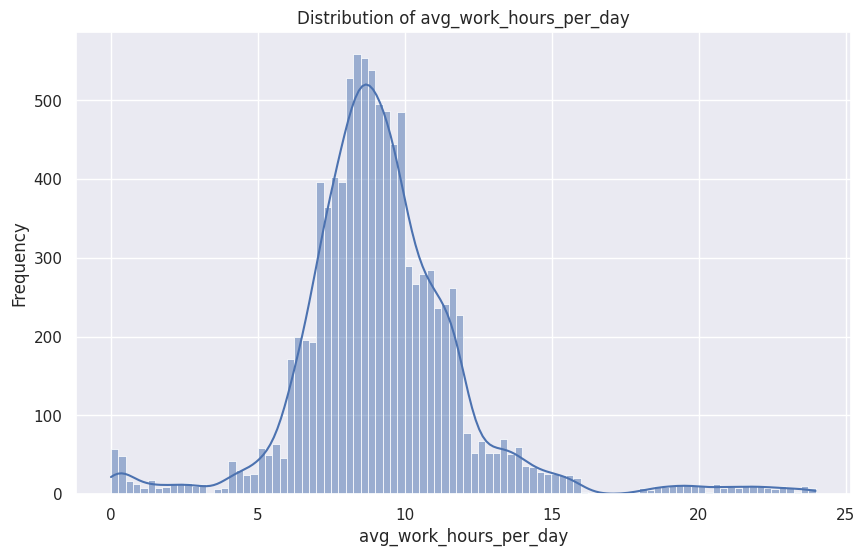

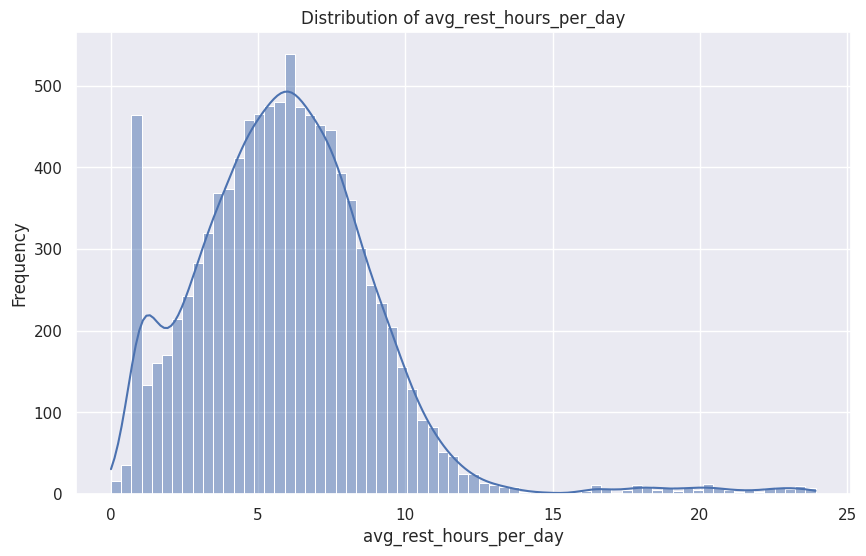

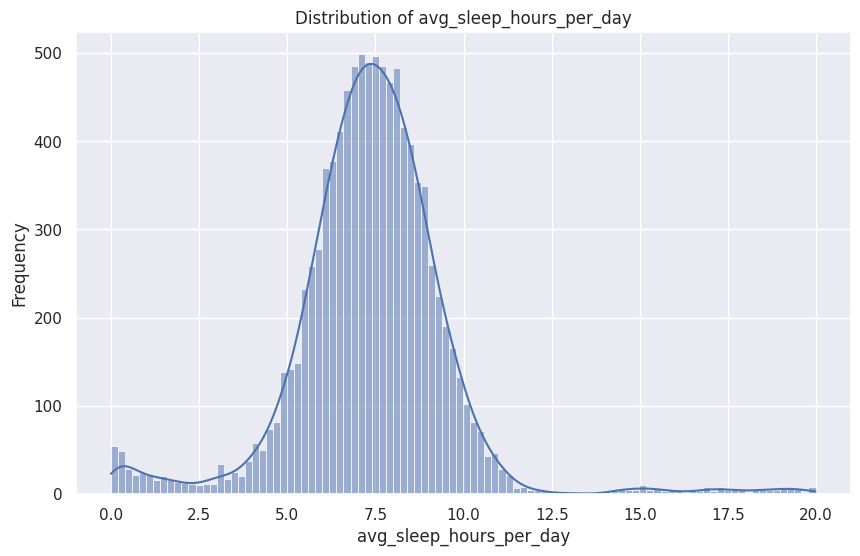

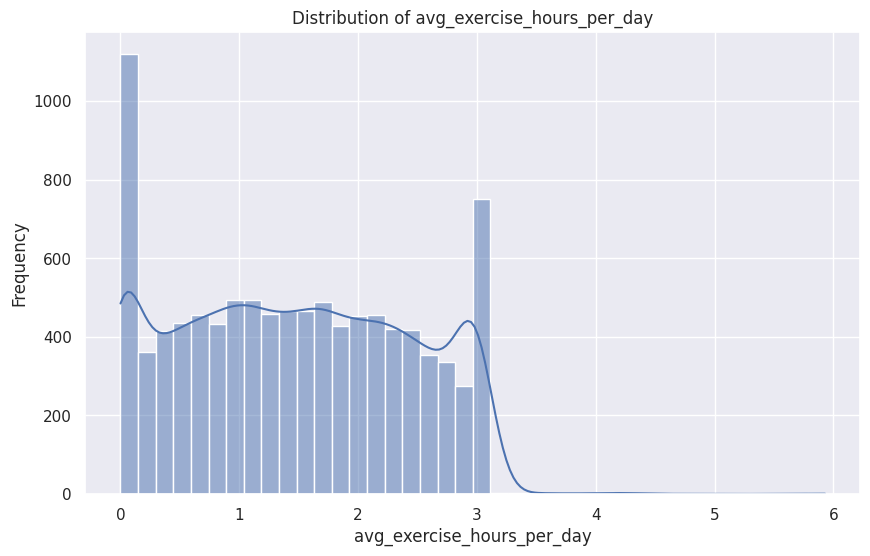

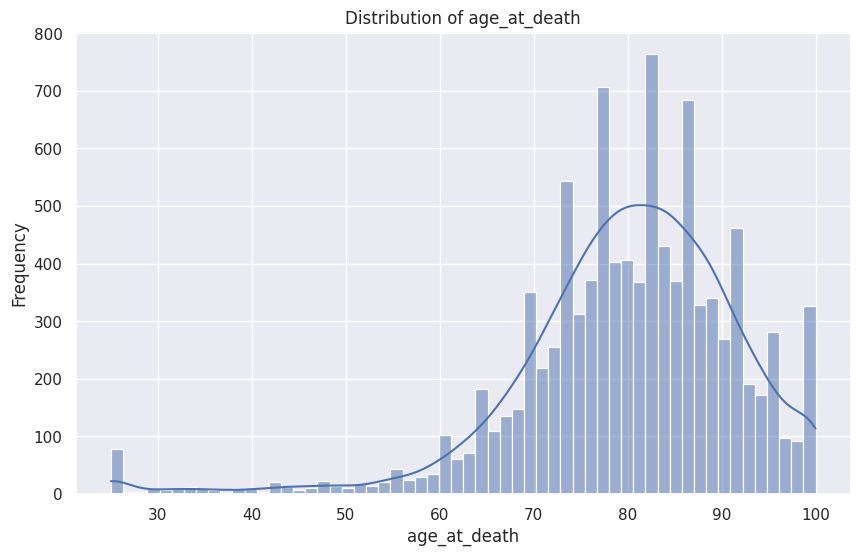

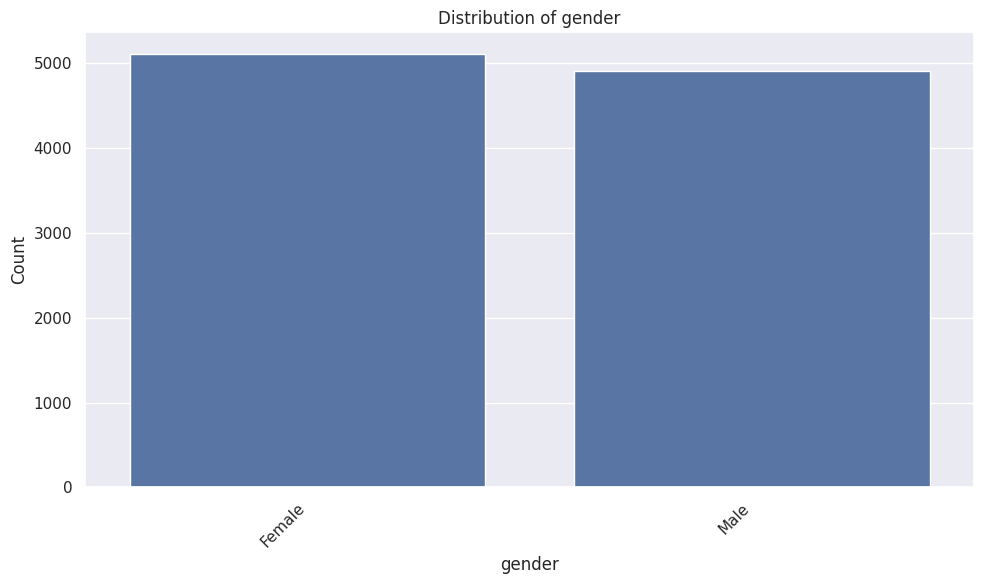

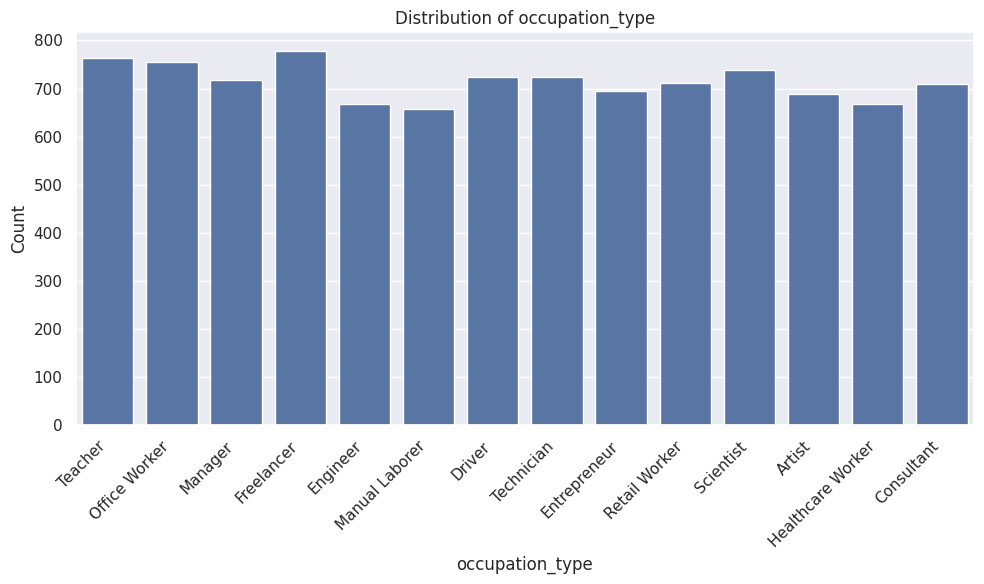

Value counts for gender:
gender
Female    5102
Male      4898
Name: count, dtype: int64

Value counts for occupation_type:
occupation_type
Freelancer           778
Teacher              764
Office Worker        755
Scientist            738
Driver               725
Technician           724
Manager              717
Retail Worker        712
Consultant           710
Entrepreneur         694
Artist               688
Healthcare Worker    669
Engineer             668
Manual Laborer       658
Name: count, dtype: int64



In [14]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

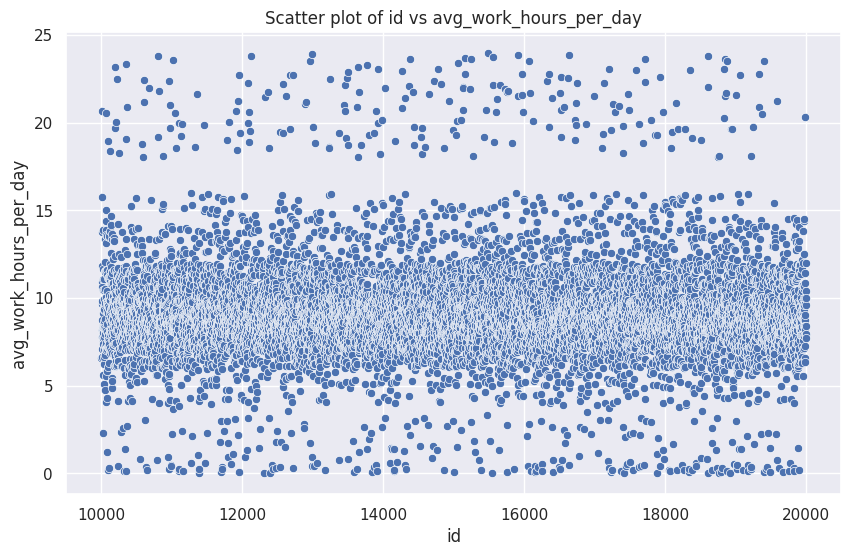

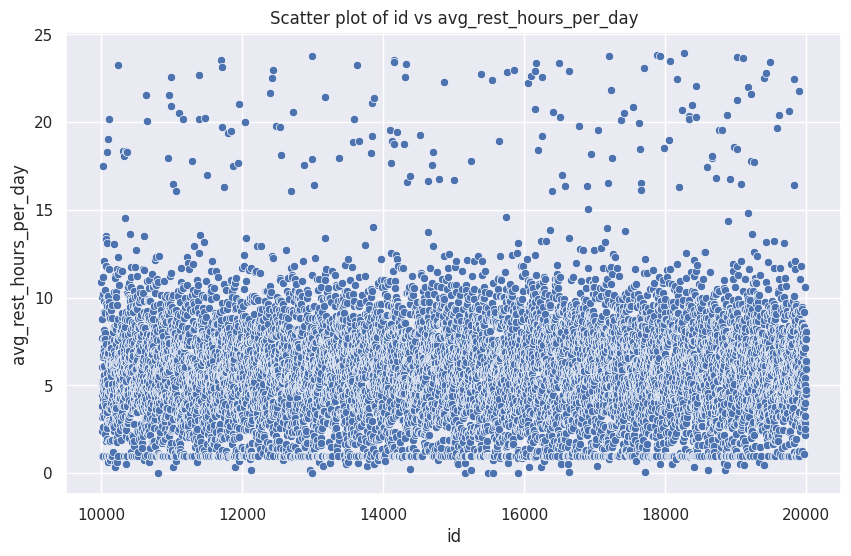

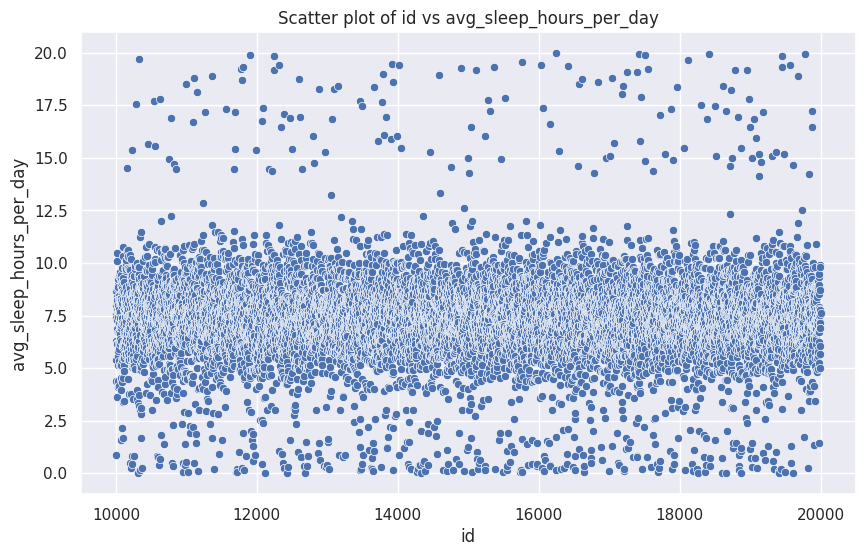

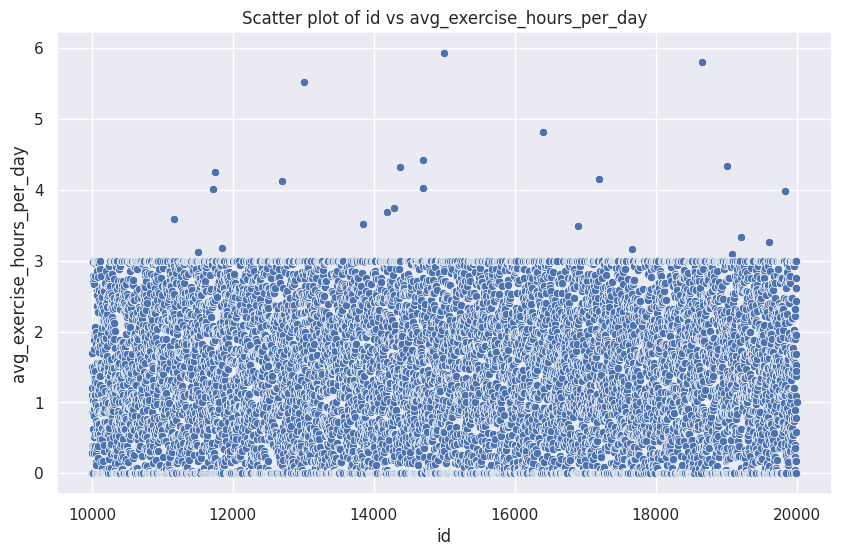

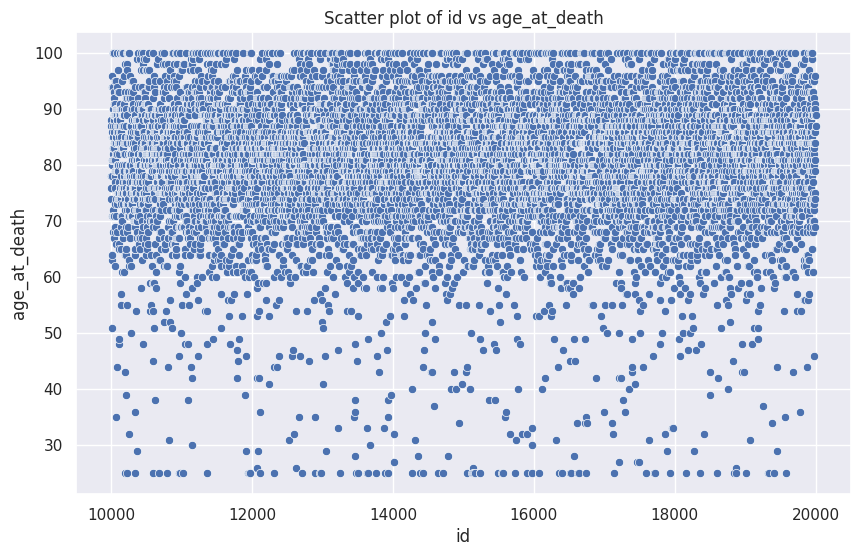

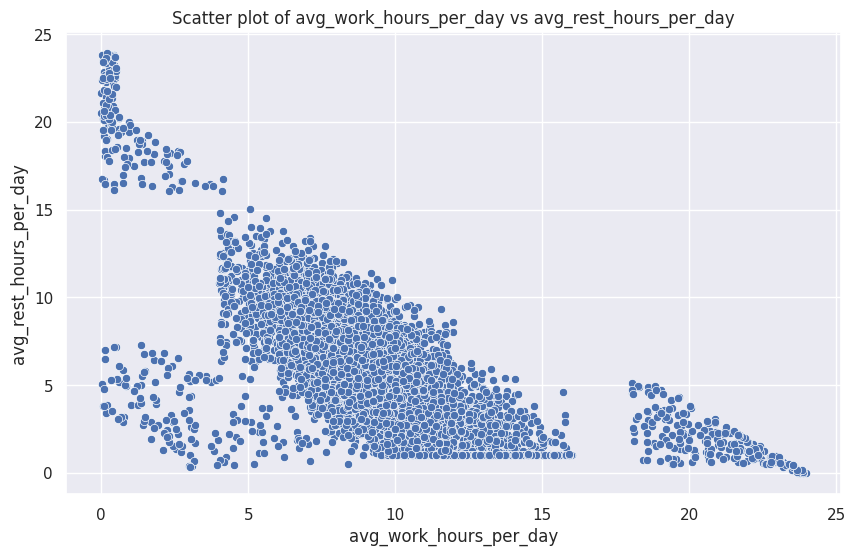

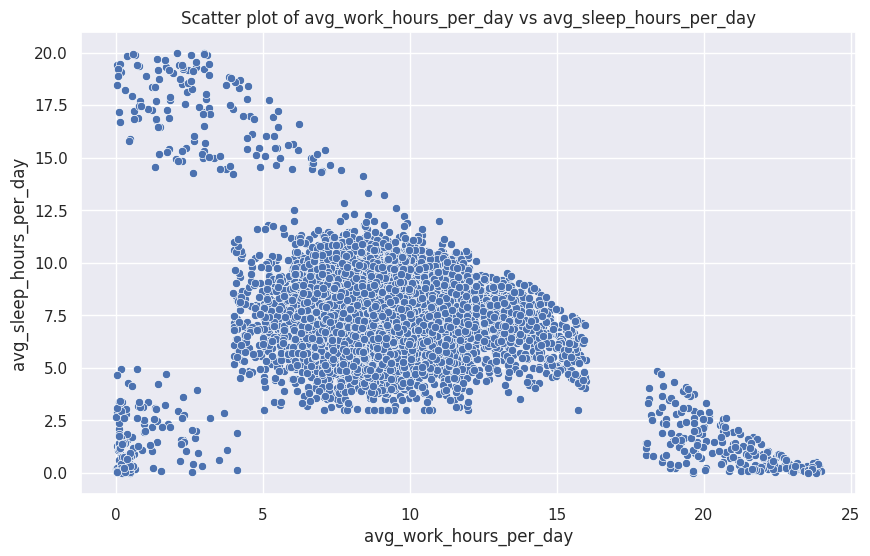

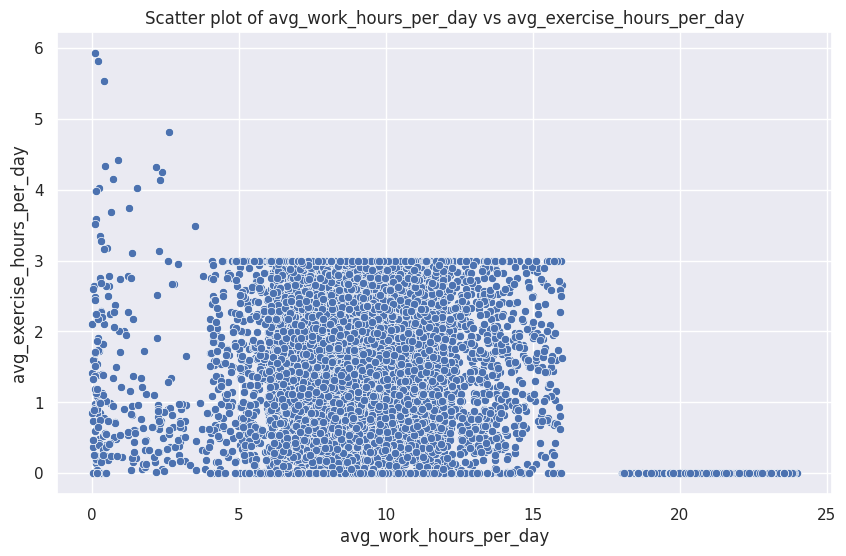

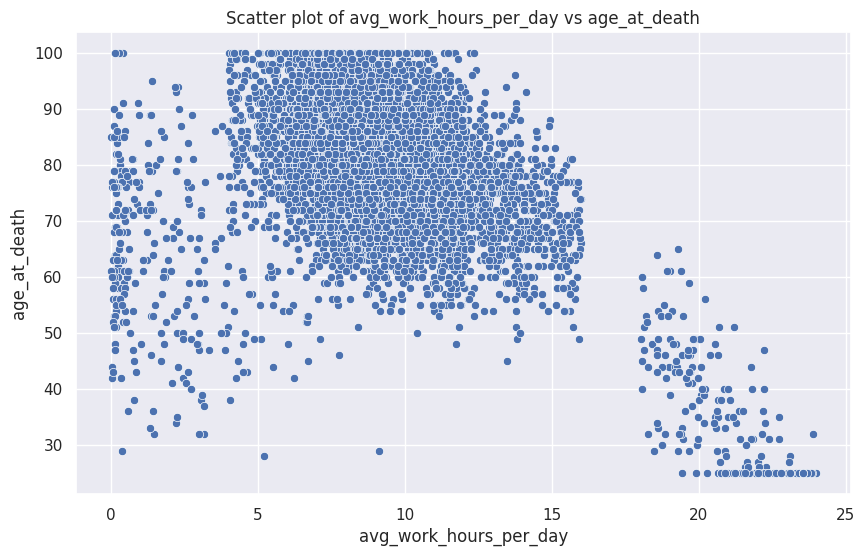

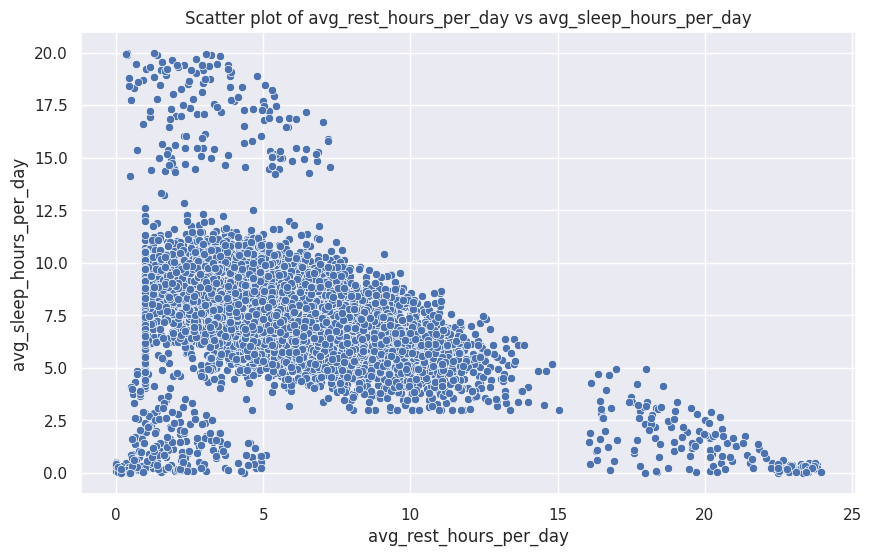

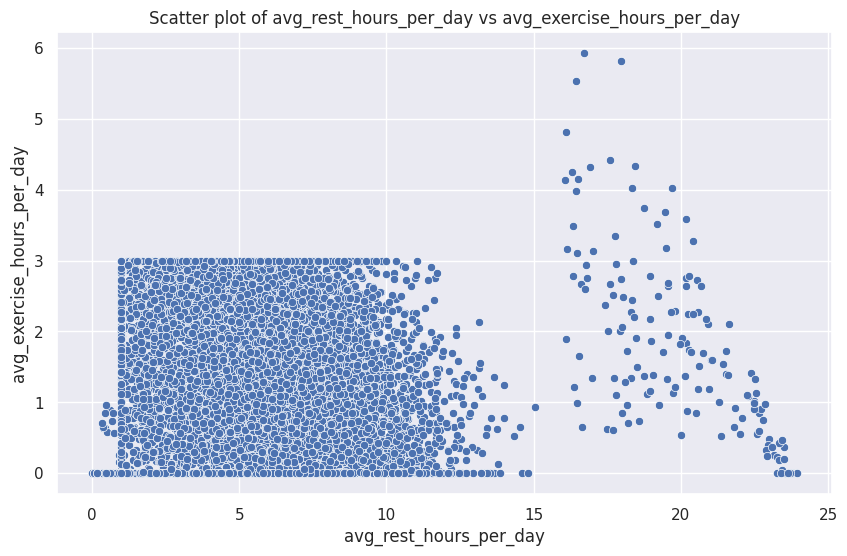

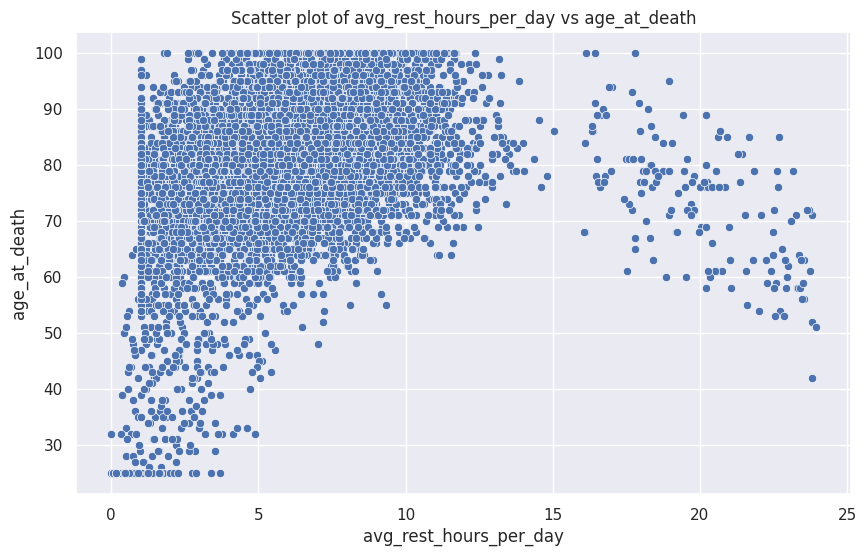

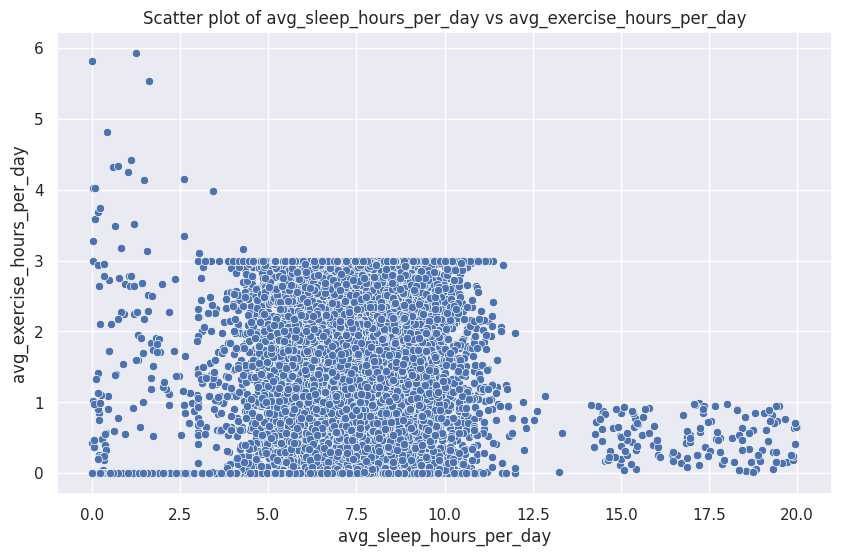

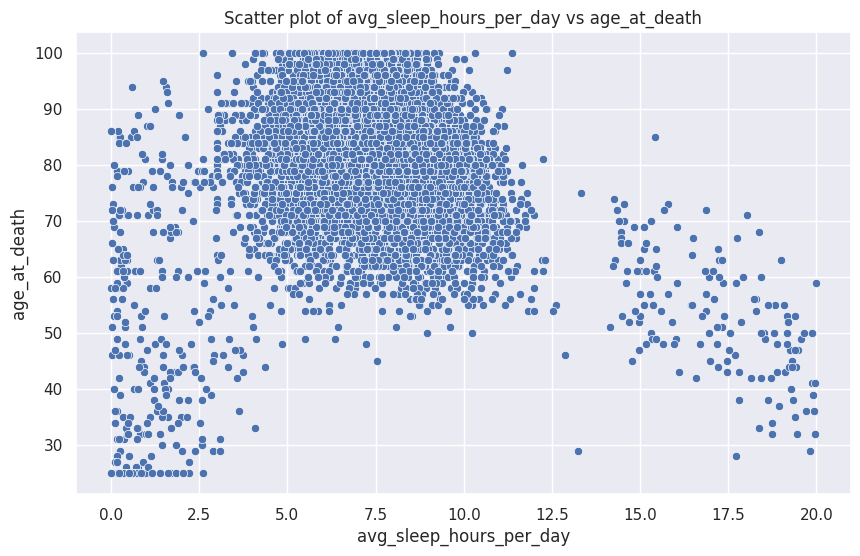

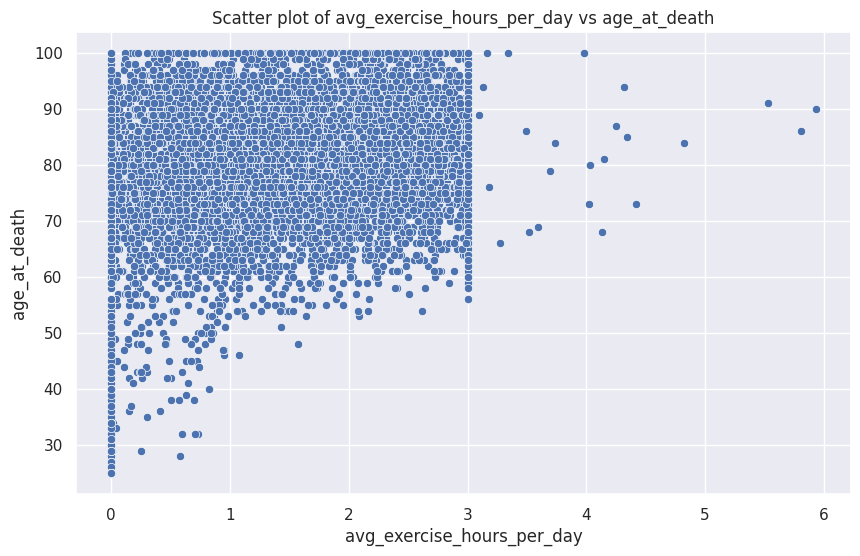

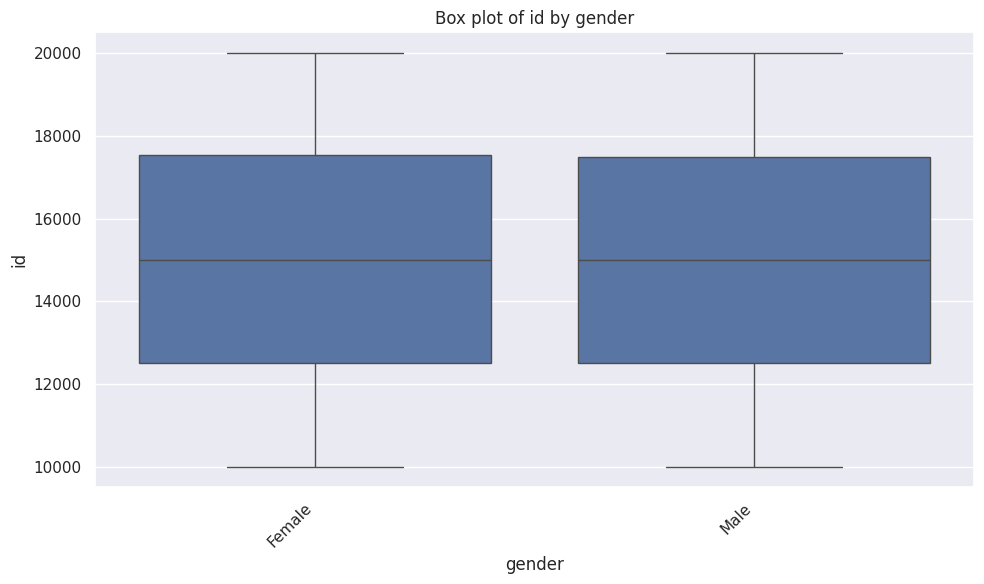

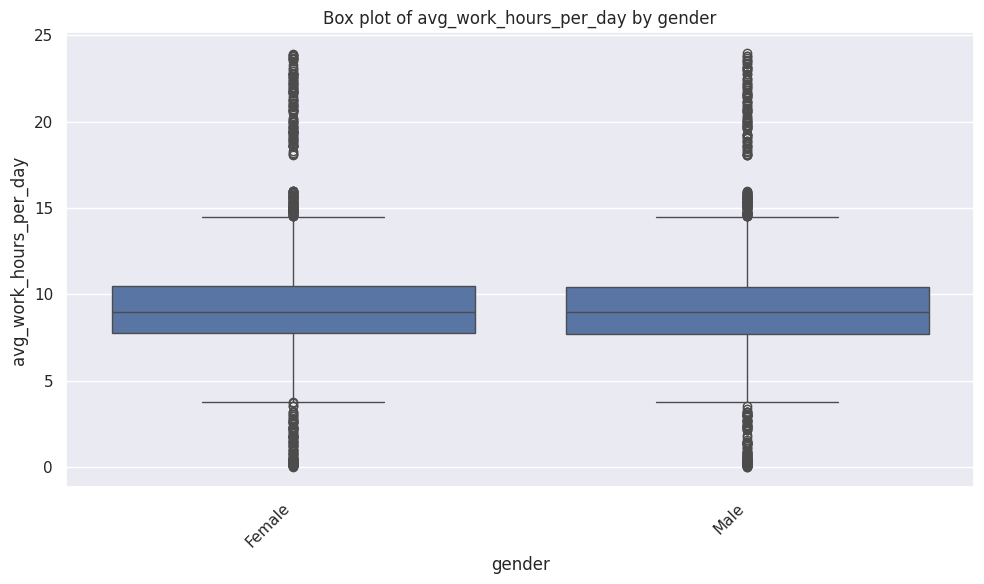

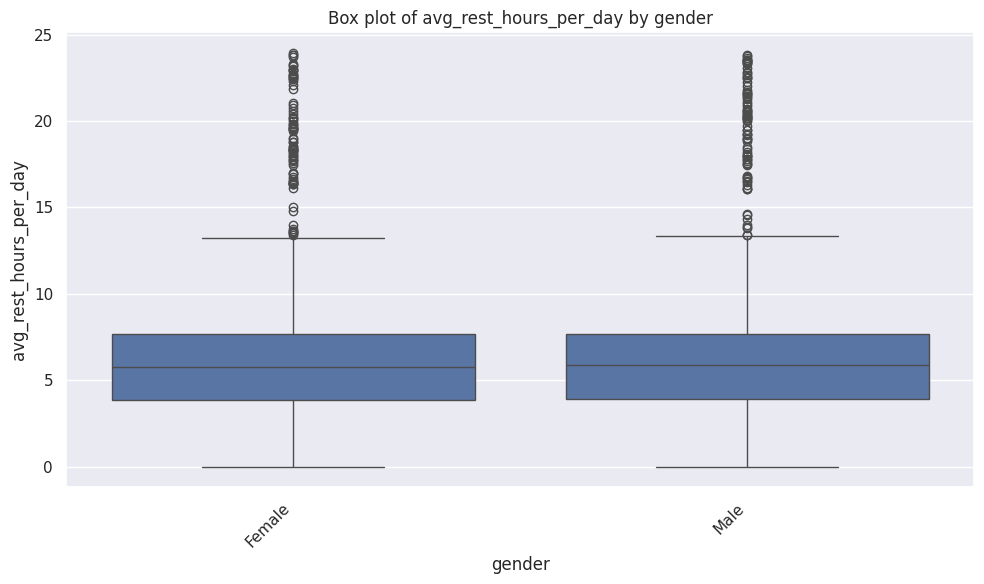

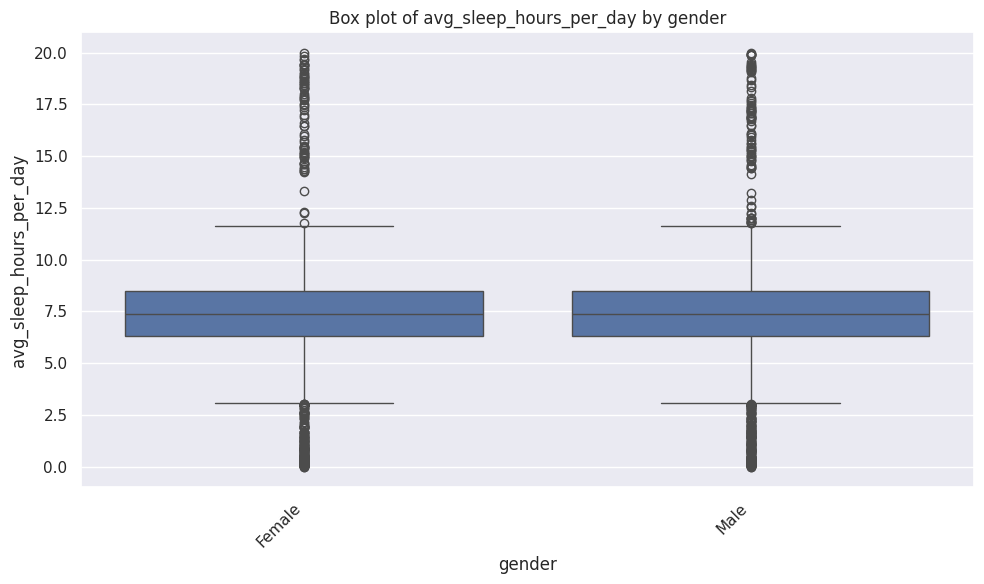

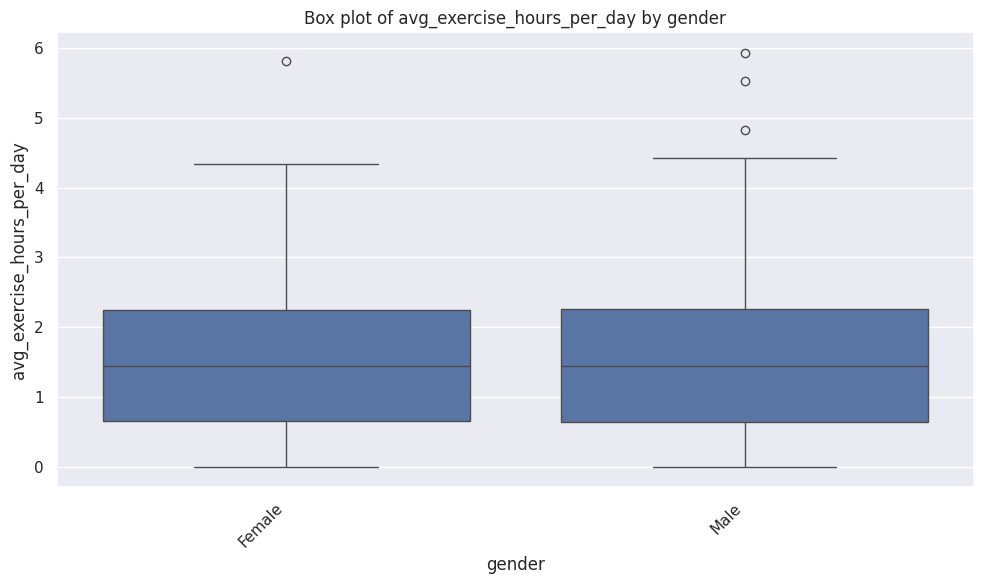

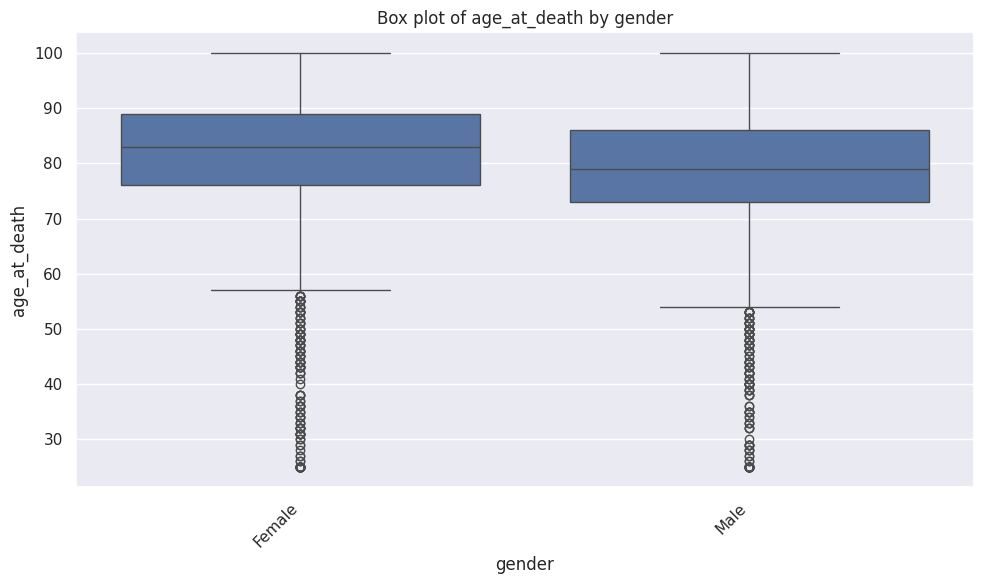

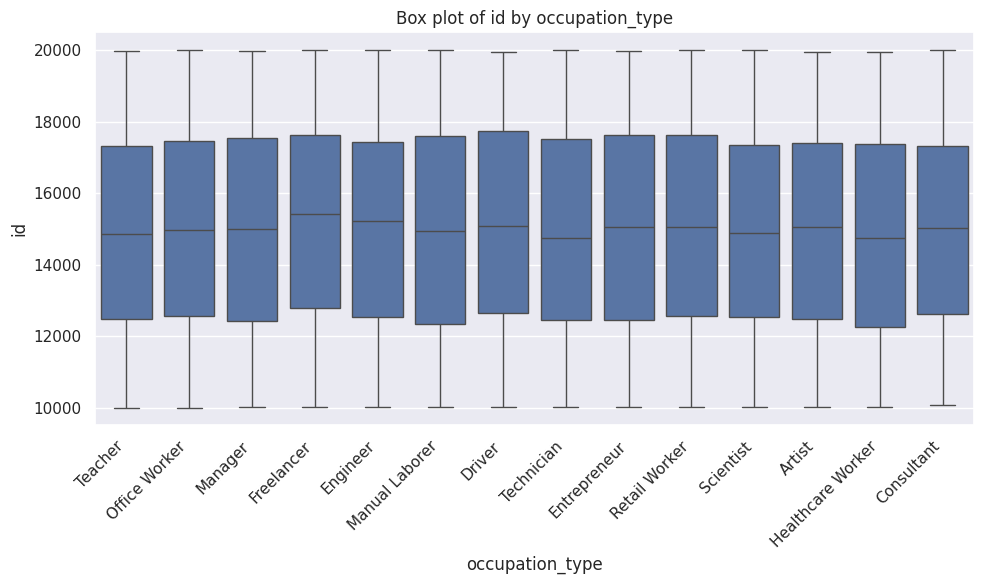

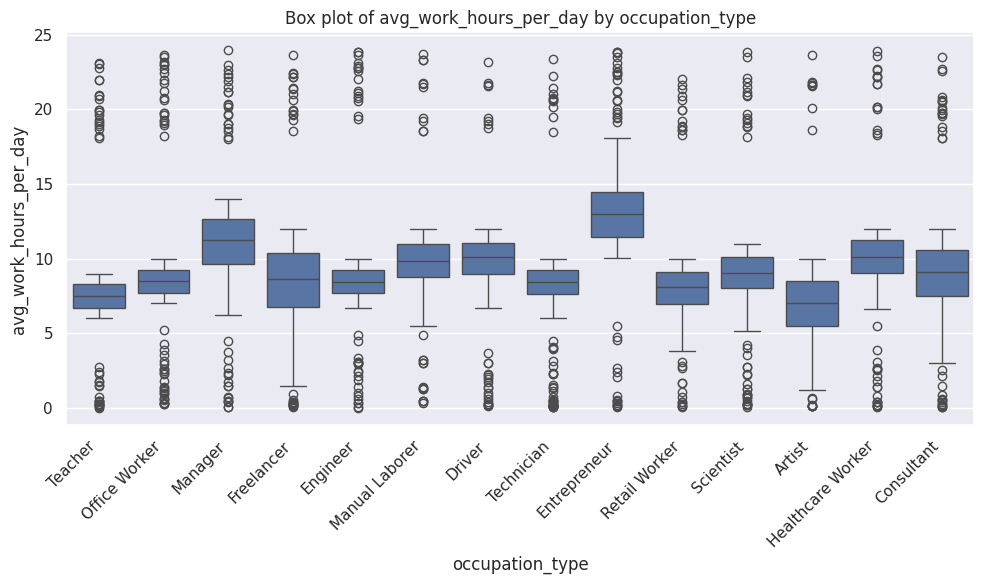

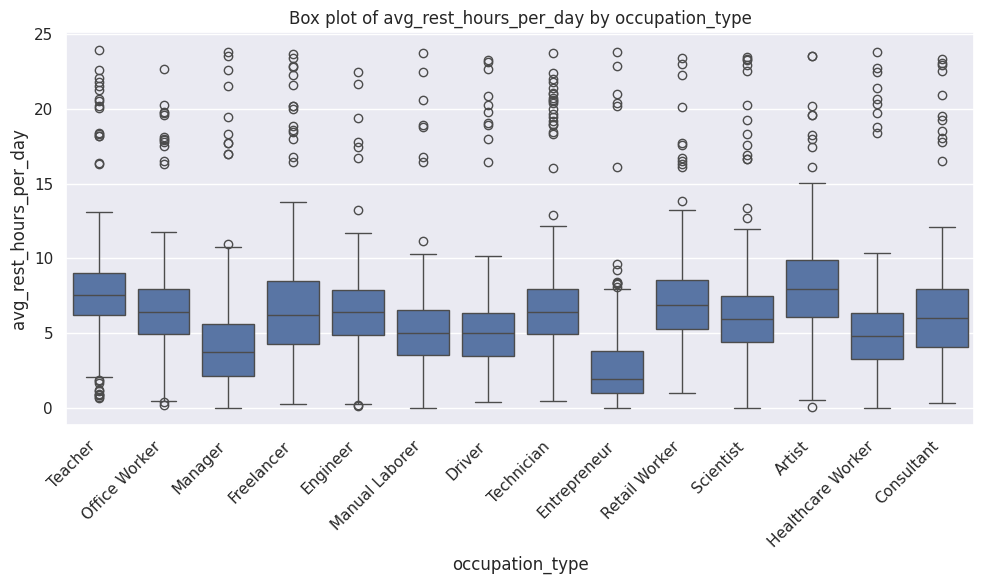

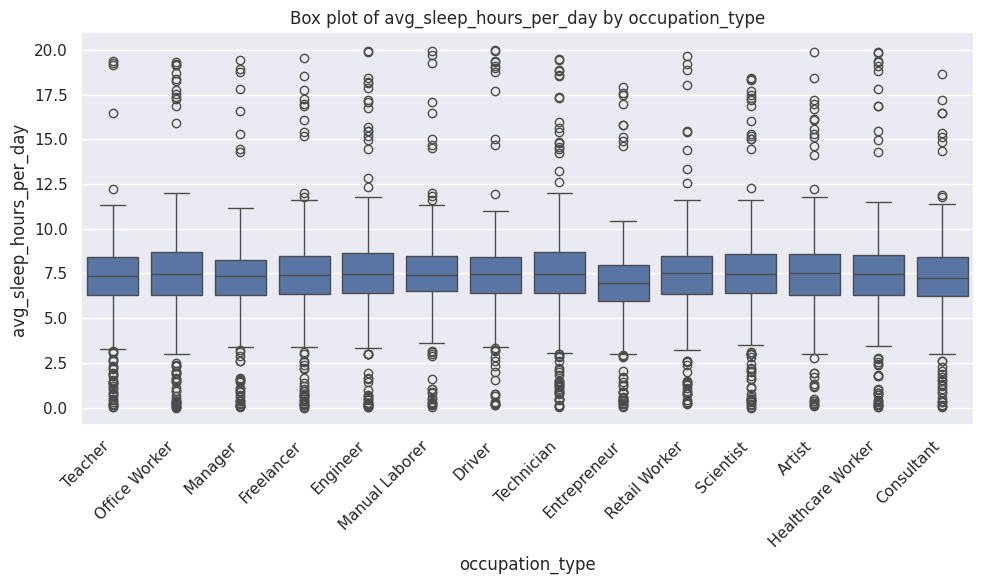

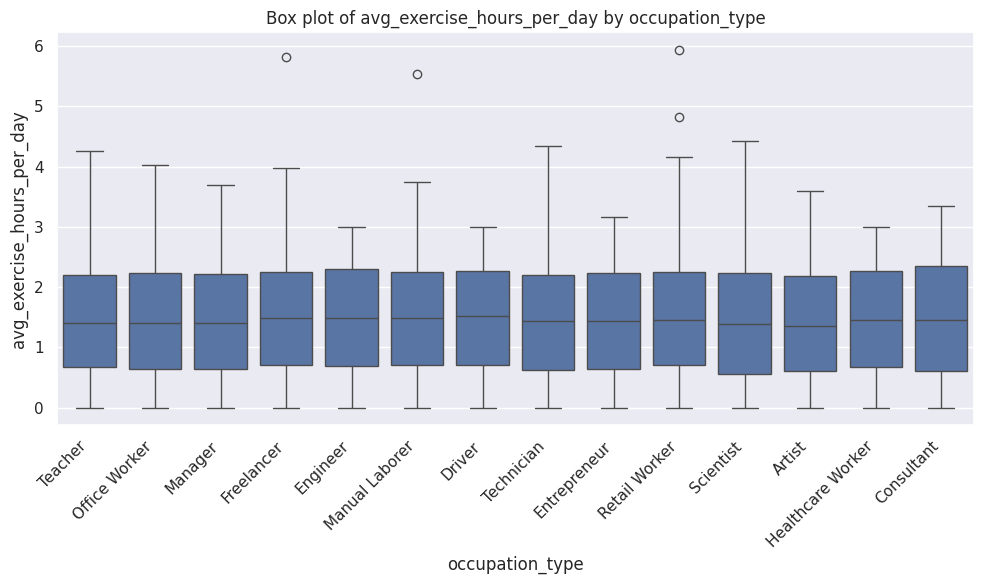

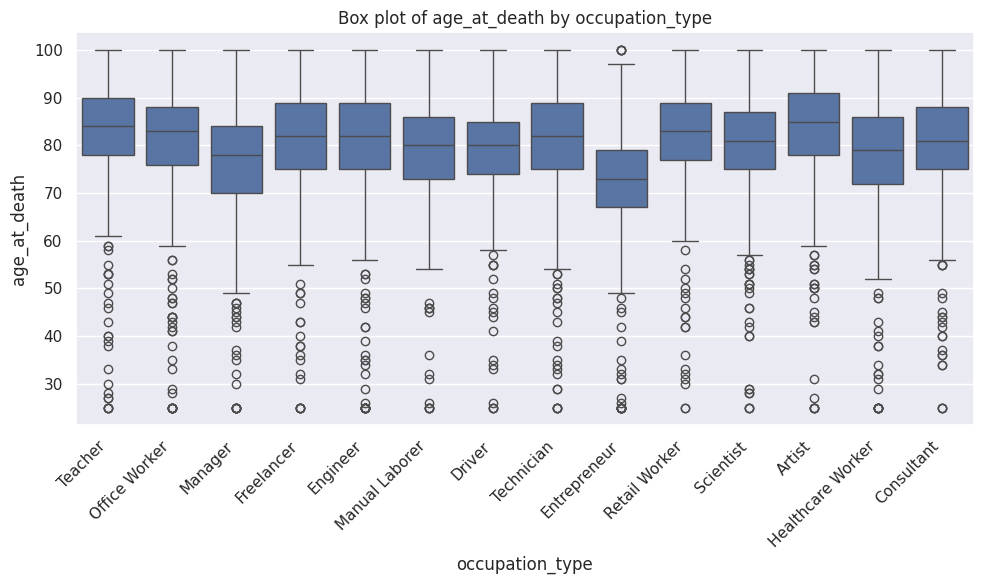

In [15]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()


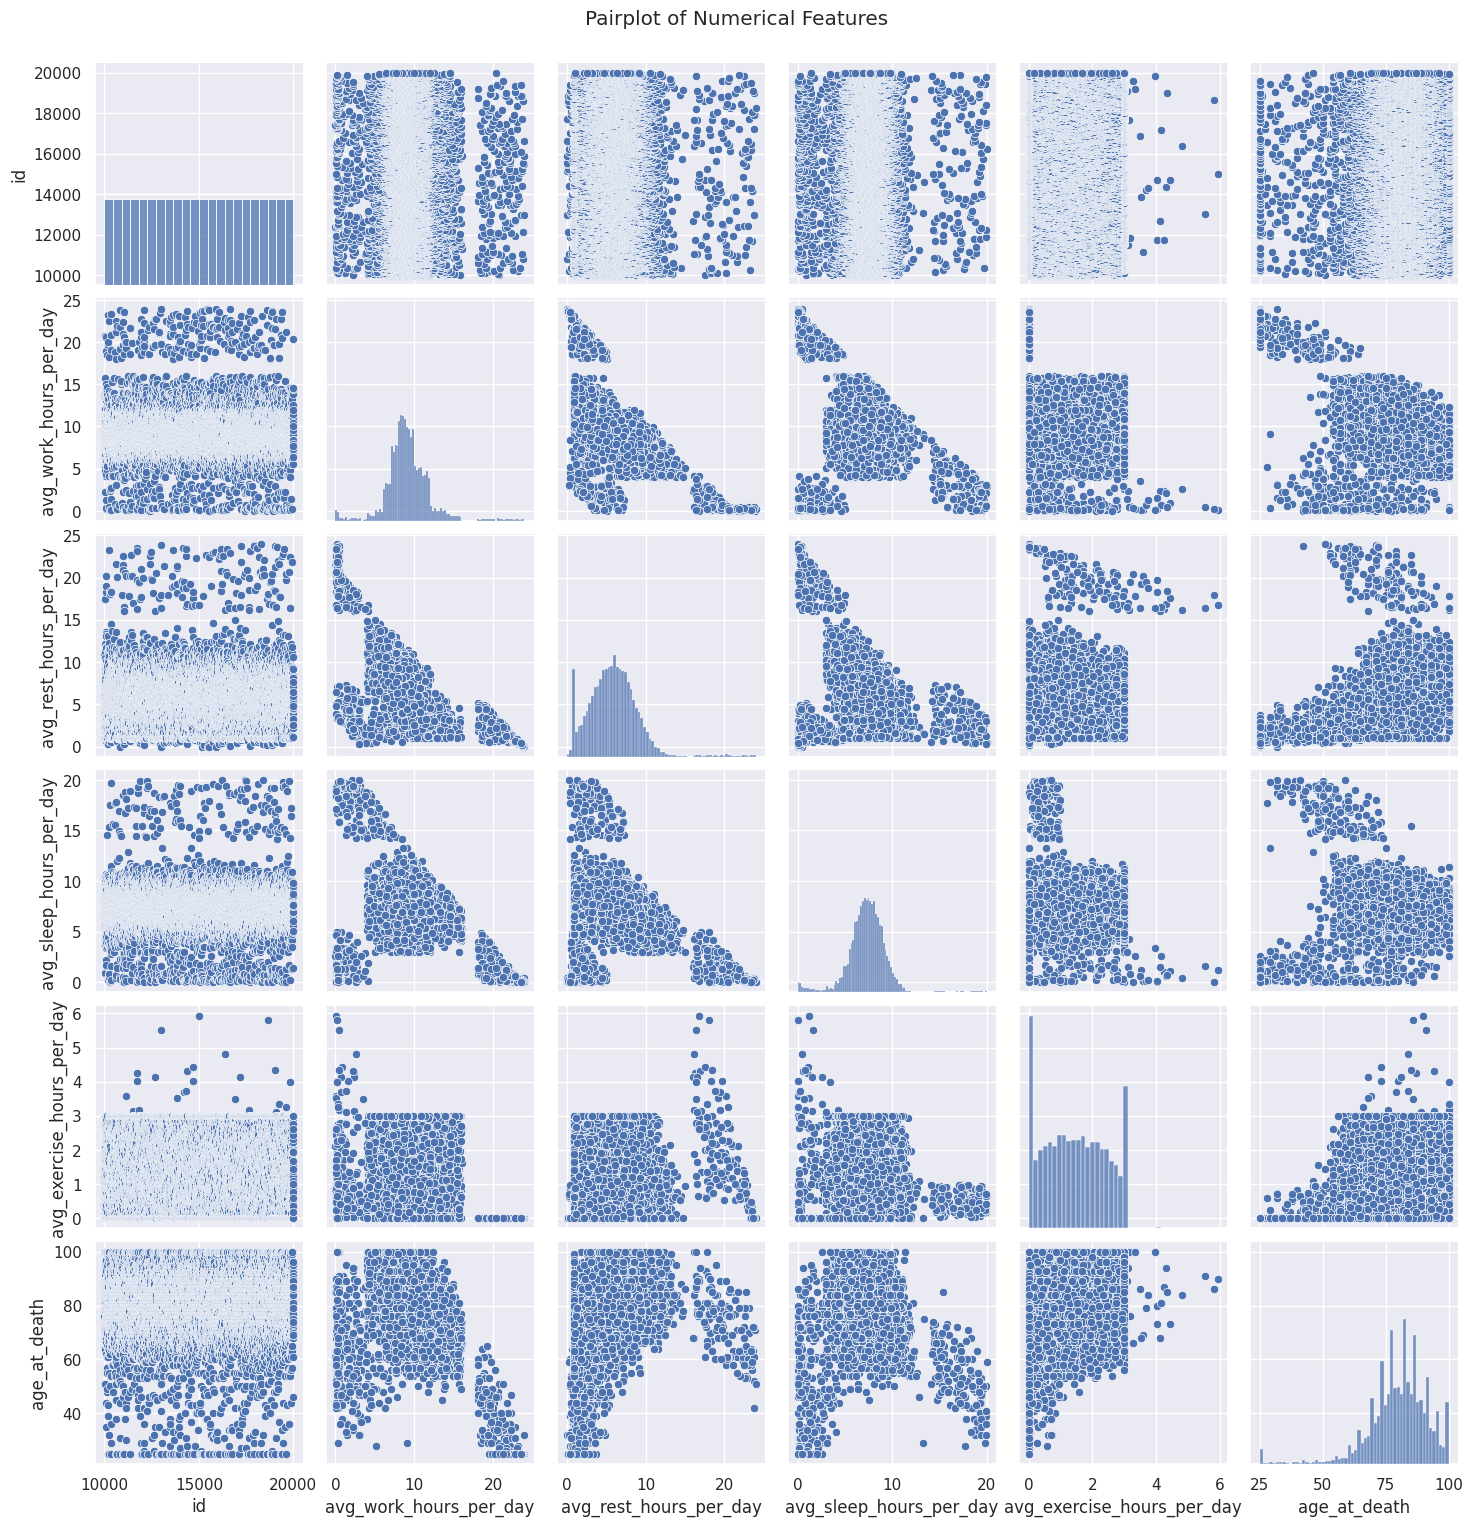

In [16]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

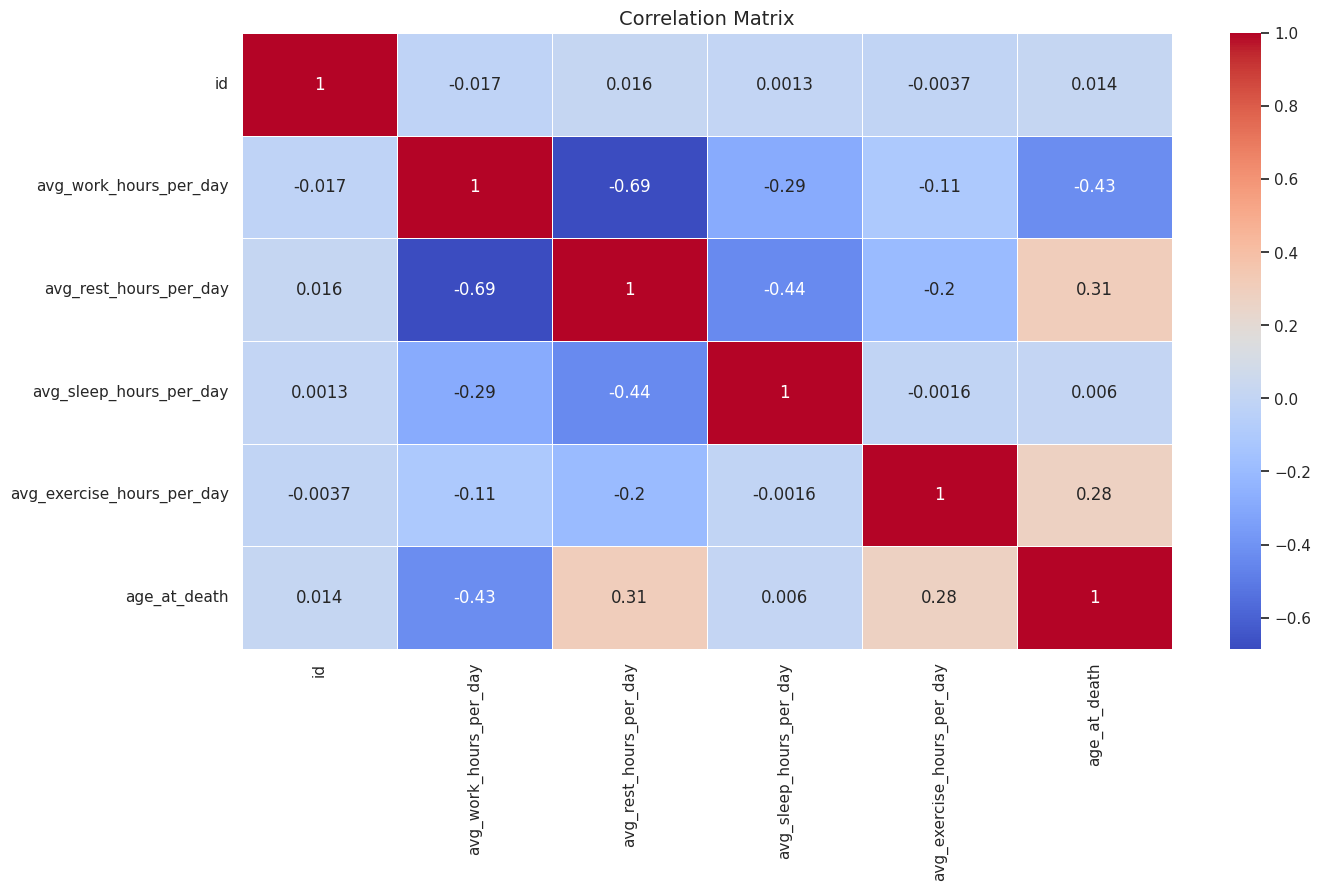

In [17]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank You